# Simulation Study

In this Jupyter Notebook, the simulation study of the Masterthesis "Regression for Large Matrices with Joint Column and Row Reduction is performed.
Therefore, the following steps are covered:
- Importing required packages and functions
- Data Loading
- Application of Scoring Mechanisms such as Leverage Scores, Cross Leverage Scores, Random Scores and combined Scores
- Application of Column Reduction
- Application of Row Reduction
- Regression using linear models
- Evaluation of models and scoring mechanisms

In [123]:
#==============================================================================================
# Packages: Import of required packages for the simulation study
#==============================================================================================
%load_ext autoreload
%autoreload 2

import pandas as pd
from pathlib import Path
import random
from functions import get_leverage_scores, get_cross_leverage_scores, get_random_scores, get_combined_scores, \
    row_reduction, column_reduction
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from plotnine import ggplot, aes, geom_histogram, theme_bw, labs, geom_line, theme_minimal
from IPython.display import display

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data")
folder = "p1000_n900"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
#==============================================================================================
# Data Loading: Import the simulated data sets from corresponding folders
#==============================================================================================

## initialize lists to store data
df_train = []
df_test = []
y_train = []
y_test = []

## read in the simulation data
for i in range(10):
    df_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/X_train.csv")
    )
    df_test.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/X_test.csv")
    )
    y_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/y_train.csv")
    )
    y_test.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/y_test.csv")
    )

print("Shape of Training Data: ", np.shape(df_train[0]))
df_train[0].head()

Shape of Training Data:  (720, 1000)


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.48940763,-1.3365464,-1.1138309,-0.4529517,1.6798241,-1.0300092,2.4265904,0.036485665,-0.9186341,-1.138299,...,1.0622252,0.27532765,0.78732353,0.17963603,-1.0355898,-0.019407177,-0.7403436,-1.9321772,1.1586596,-0.39525935
1,-0.95737004,0.045942705,-0.772199,1.0898916,-1.5788925,-0.95179075,-0.30889553,0.9685488,1.6352783,0.14434673,...,0.9248747,1.2113984,-1.2162019,-0.00029110722,1.9223812,-0.98204535,-1.3869884,-1.4774071,0.031359687,-0.13555853
2,-1.6415124,-2.3851411,1.4885222,-0.5683536,0.6096026,-0.3897477,1.7956898,-2.2578754,-0.4421387,0.15759848,...,-0.19137459,0.46999124,-1.6077456,0.72388417,-0.82483006,-0.7092231,-0.32290763,1.1495969,-0.968917,-0.16925187
3,0.9733367,-0.24864665,1.1663989,-0.9174811,0.9850009,-0.25291964,1.6127403,-1.3349732,-0.12970851,0.8061096,...,-1.0790758,0.0062031955,-0.114922,0.95770645,1.0548818,0.44111162,-0.304699,0.80287564,-1.439379,-1.5027109
4,0.58487713,-2.3099463,-0.095216036,-0.24510498,-0.9888419,1.0235603,0.6145533,0.027057976,-0.5657045,-1.6955075,...,1.3870474,1.6727191,-0.42102033,0.4229156,0.4812275,0.6687485,0.037214383,0.37430185,0.09666948,-1.3065377


In [127]:
#==============================================================================================
# Parameter Setting: Set the rank parameter and the seed of the script for reproducibility
#==============================================================================================

## set the seed
random.seed(1)

## set the basis parameters
k = 25
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

c =  81.0
r =  356.0


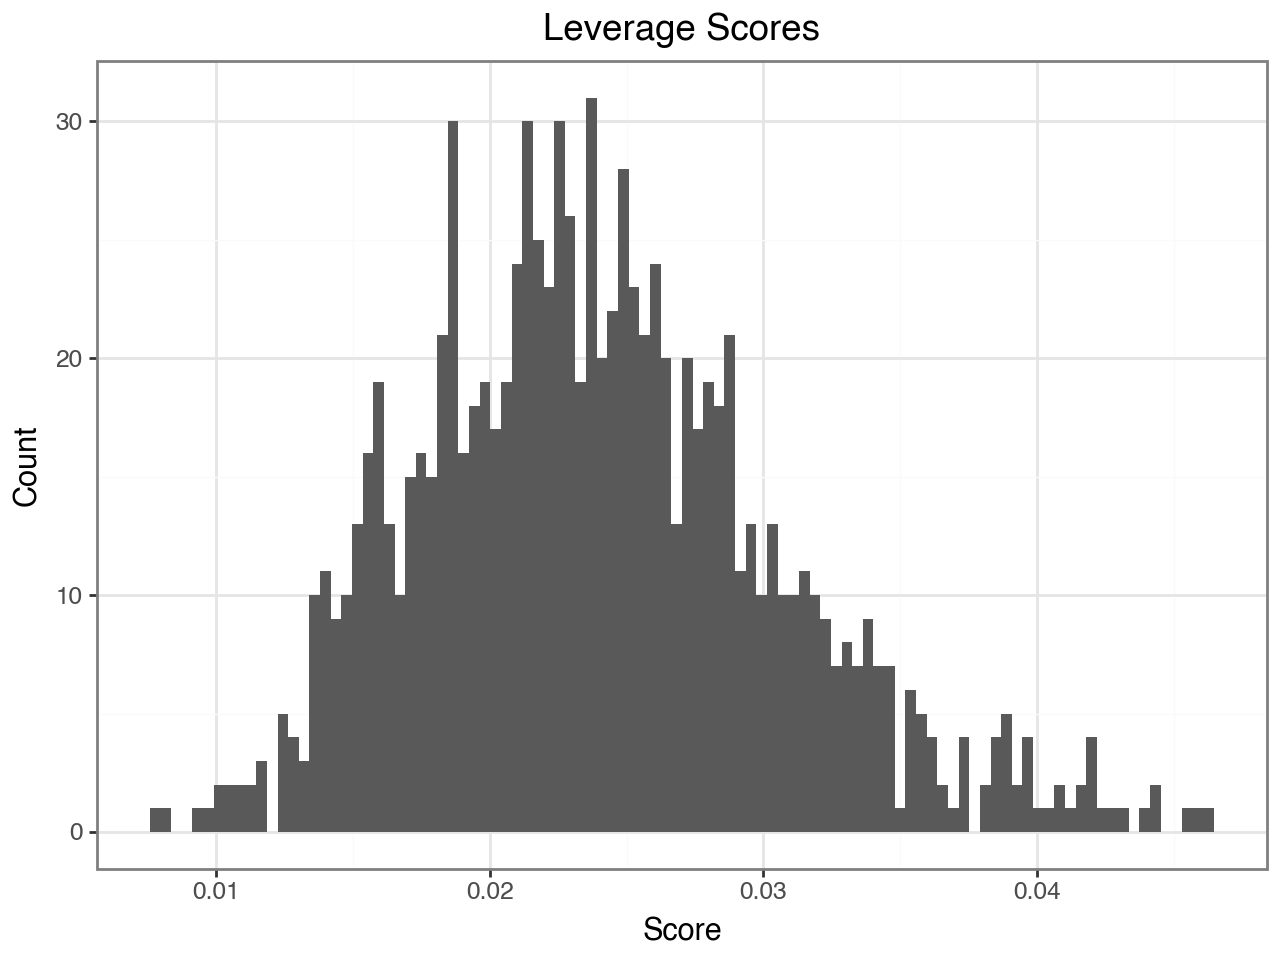

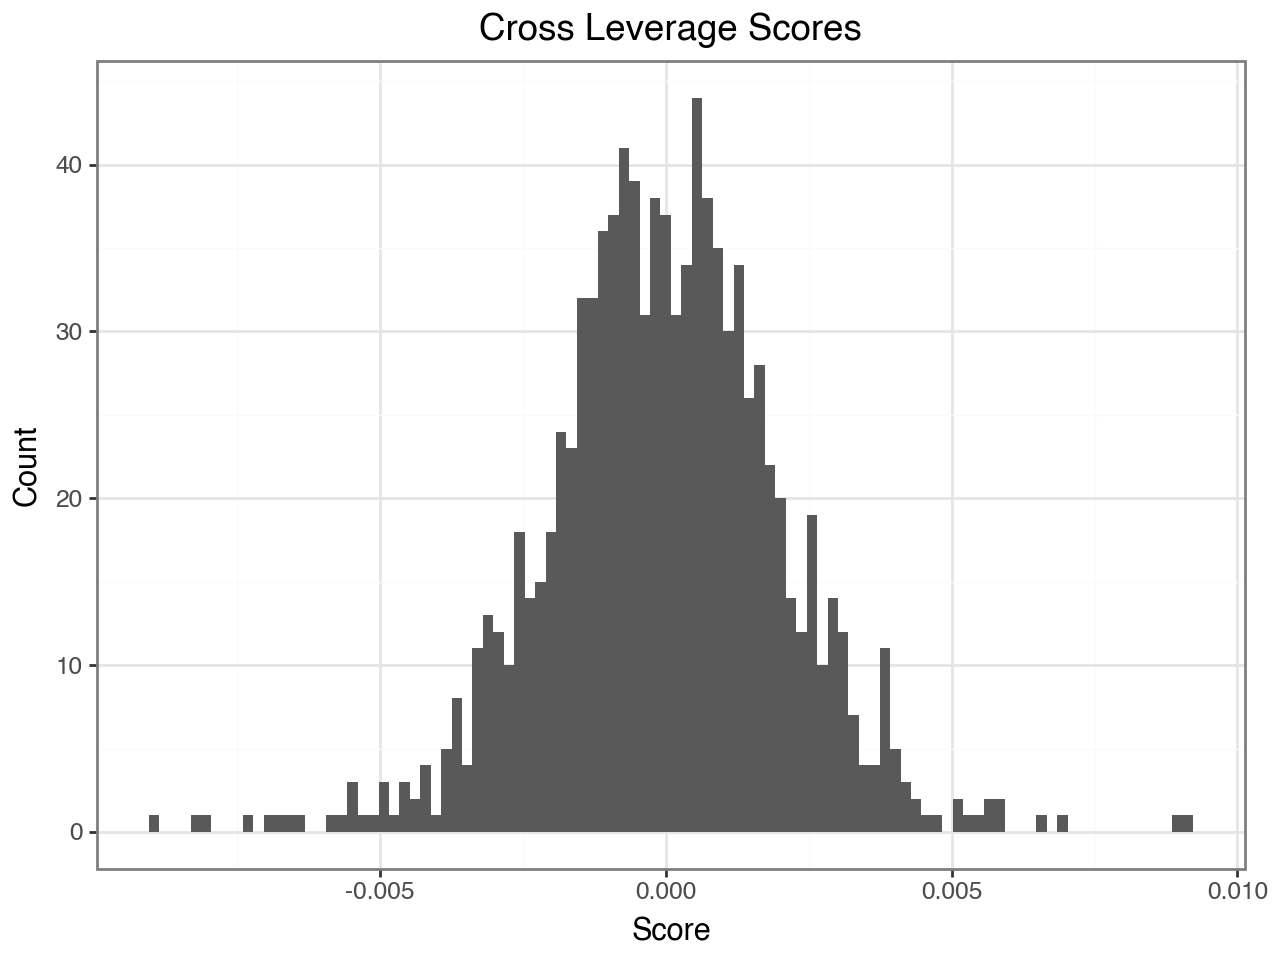

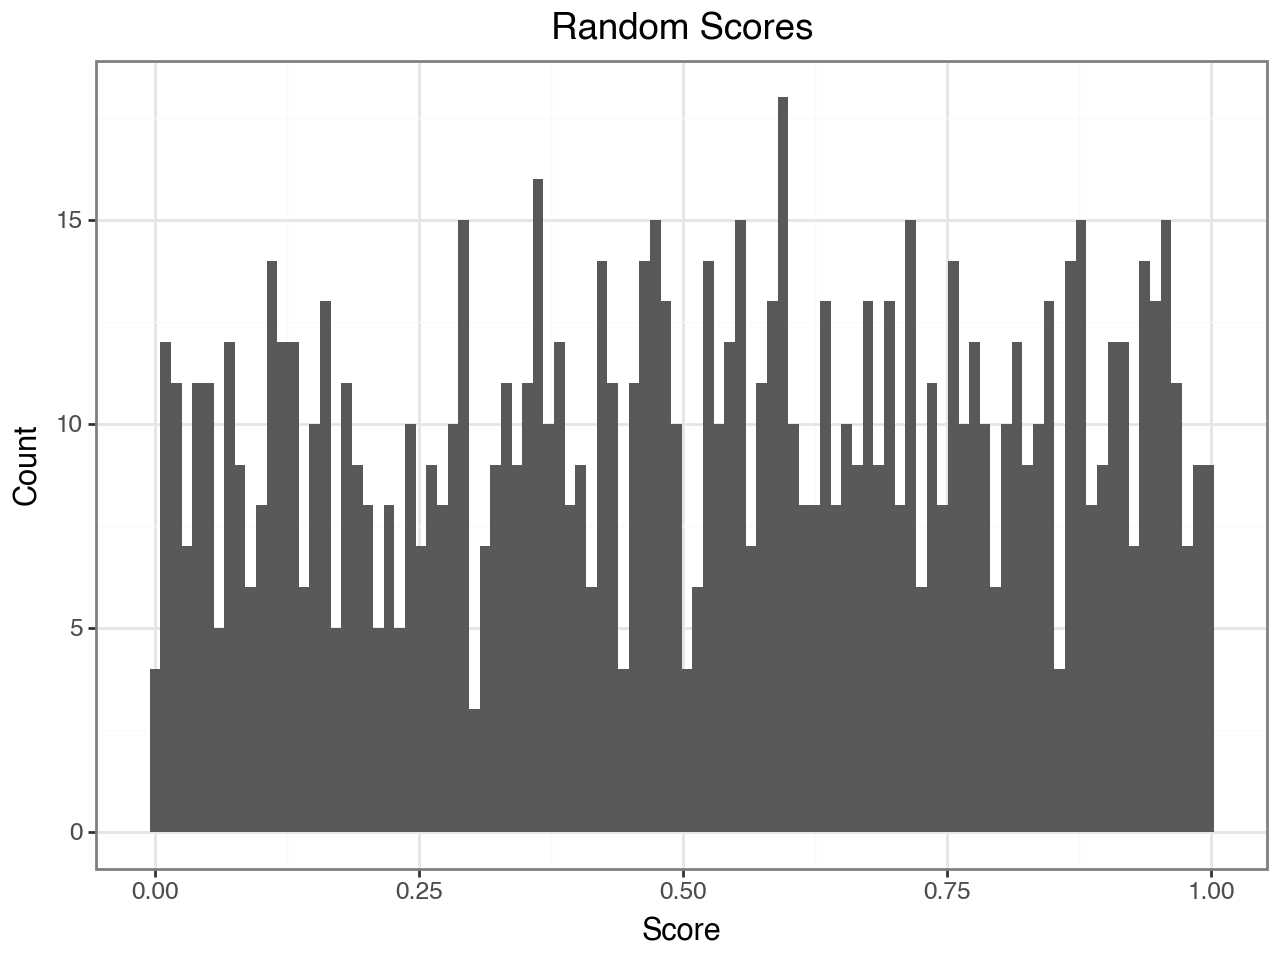

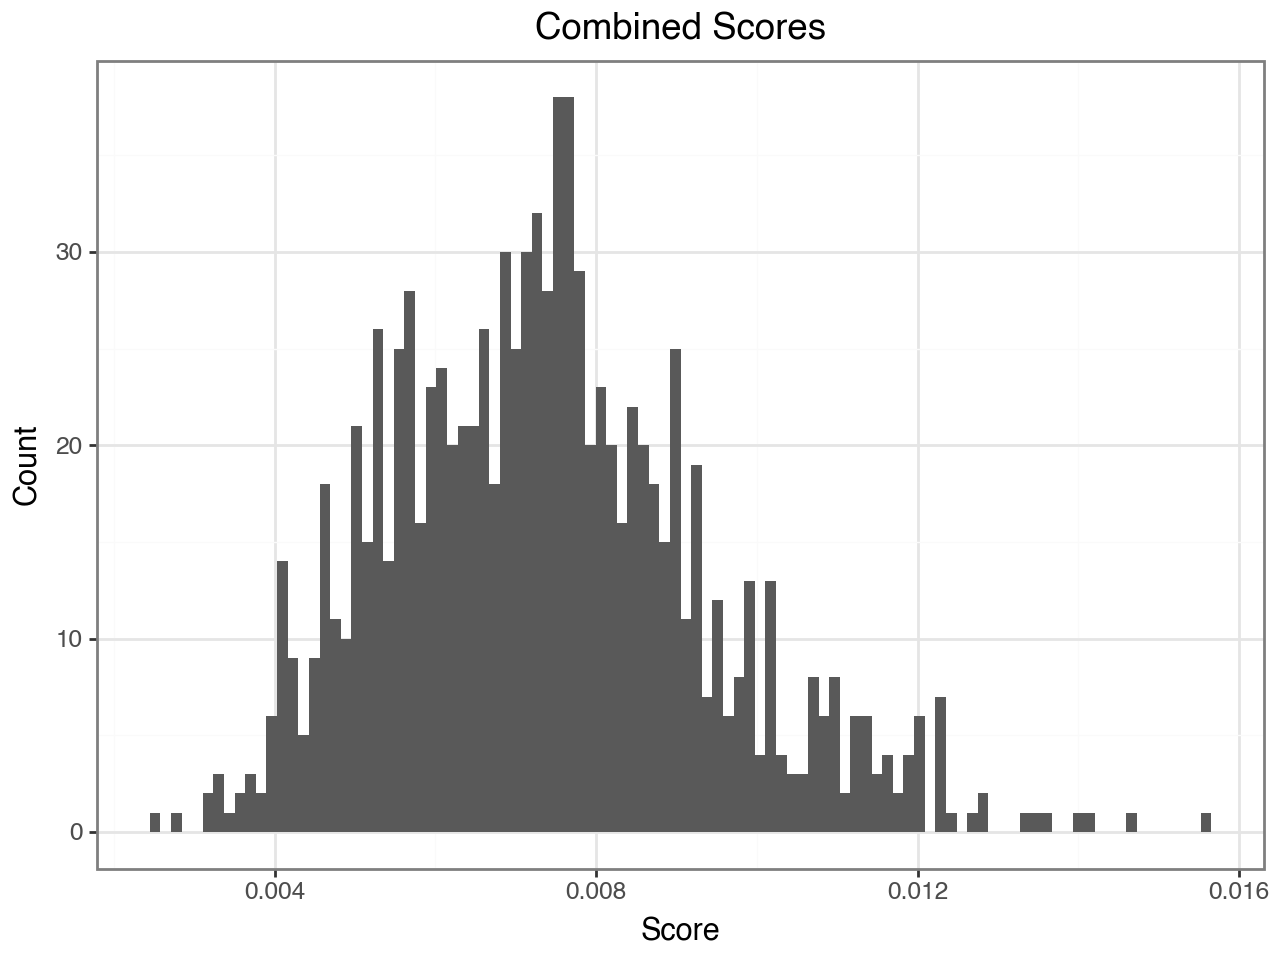

In [128]:
#==============================================================================================
# Scoring Mechanisms: Application of different scoring functions to the training data
#==============================================================================================

## Calculate the scores per data frame
column_ls = []
column_cls = []
column_rs = []
column_cs = []

for i in range(10):
    column_ls.append(get_leverage_scores(df_train[i], k))
    column_cls.append(get_cross_leverage_scores(df_train[i], y_train[i]))
    column_rs.append(get_random_scores(df_train[i]))
    column_cs.append(get_combined_scores(df_train[i], y_train[i], k, p_leverage = 0.2))

## Investigation of distributions
df_ls  = pd.DataFrame({'value': column_ls[0]})
df_cls = pd.DataFrame({'value': column_cls[0]})
df_rs  = pd.DataFrame({'value': column_rs[0]})
df_cs  = pd.DataFrame({'value': column_cs[0]})

display(
    ggplot(df_ls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_cls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Cross Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_rs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Random Scores', x='Score', y='Count')
)

display(
    ggplot(df_cs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Combined Scores', x='Score', y='Count')
)

In [129]:
#==============================================================================================
# Column Reduction: Application of column reduction mechanism
#==============================================================================================

## Calculation of column reduction
C_ls = []
C_cls = []
C_rs = []
C_cs = []

for i in range(10):
    C_ls.append(column_reduction(df_train[i], column_ls[i], k))
    C_cls.append(column_reduction(df_train[i], column_cls[i], k))
    C_rs.append(column_reduction(df_train[i], column_rs[i], k))
    C_cs.append(column_reduction(df_train[i], column_cs[i], k))

In [130]:
#==============================================================================================
# Row Reduction: Application of row reduction mechanism
#==============================================================================================

## Calculation of row reduction
R_ls = []
R_cls = []
R_rs = []
R_cs = []

for i in range(10):
    R_ls.append(row_reduction(C_ls[i]['C'], y_train[i], k))
    R_cls.append(row_reduction(C_cls[i]['C'], y_train[i], k))
    R_rs.append(row_reduction(C_rs[i]['C'], y_train[i], k))
    R_cs.append(row_reduction(C_cs[i]['C'], y_train[i], k))

This function is designed for the case n < p. The matrix is now getting transposed.
(720, 1)
(324,)
<class 'pandas.DataFrame'>
<class 'list'>
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
(720, 1)
(396,)
<class 'pandas.DataFrame'>
<class 'list'>
This function is designed for the case n < p. The matrix is now getting transposed.
(720, 1)
(411,)
<class 'pandas.DataFrame'>
<class 'list'>
This function is designed for the case n < p. The matrix is now getting transposed.
(720, 1)
(403,)
<class 'pandas.DataFrame'>
<class 'list'>
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
(720, 1)
(256,)
<class 'pandas.DataFrame'>
<class 'list'>
This function is designe

In [131]:
#==============================================================================================
# Linear Modeling: Application of linear model to reduced data sets, and RMSE calculations
#==============================================================================================

## Fit linear models to the reduced data matrix
model_ls = []
model_cls = []
model_rs = []
model_cs = []
for i in range(10):
    model = LinearRegression()
    model.fit(R_ls[i]['R'], R_ls[i]['y'])
    model_ls.append(model)
    model = LinearRegression()
    model.fit(R_cls[i]['R'], R_cls[i]['y'])
    model_cls.append(model)
    model = LinearRegression()
    model.fit(R_rs[i]['R'], R_rs[i]['y'])
    model_rs.append(model)
    model = LinearRegression()
    model.fit(R_cs[i]['R'], R_cs[i]['y'])
    model_cs.append(model)

## Build predictions
predictions_ls = []
predictions_cls = []
predictions_rs = []
predictions_cs = []
df_test_reduced_ls = []
df_test_reduced_cls = []
df_test_reduced_rs = []
df_test_reduced_cs = []
for i in range(10):
    df_test_reduced_ls.append(df_test[i].iloc[:, C_ls[i]['selected_columns']])
    predictions_ls.append(model_ls[i].predict(df_test_reduced_ls[i]))
    df_test_reduced_cls.append(df_test[i].iloc[:, C_cls[i]['selected_columns']])
    predictions_cls.append(model_cls[i].predict(df_test_reduced_cls[i]))
    df_test_reduced_rs.append(df_test[i].iloc[:, C_rs[i]['selected_columns']])
    predictions_rs.append(model_rs[i].predict(df_test_reduced_rs[i]))
    df_test_reduced_cs.append(df_test[i].iloc[:, C_cs[i]['selected_columns']])
    predictions_cs.append(model_cs[i].predict(df_test_reduced_cs[i]))

## Calculate RMSE
rmse_ls = []
rmse_cls = []
rmse_rs = []
rmse_cs = []
for i in range(10):
    rmse_ls.append(np.sqrt(mean_squared_error(y_test[i], predictions_ls[i])))
    rmse_cls.append(np.sqrt(mean_squared_error(y_test[i], predictions_cls[i])))
    rmse_rs.append(np.sqrt(mean_squared_error(y_test[i], predictions_rs[i])))
    rmse_cs.append(np.sqrt(mean_squared_error(y_test[i], predictions_cs[i])))

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester

In [132]:
#==============================================================================================
# Full Model: Application of Linear Model to the optimal set of columns
#==============================================================================================
beta_train = []
rmse_full = []
for i in range(10):
    beta_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/beta.csv")
    )
    beta = np.array(beta_train[i])
    selected_cols = np.where(beta != 0)[0]

    # Train Data Reduction
    X_train_sel = df_train[i].iloc[:, selected_cols]
    X_test_sel = df_test[i].iloc[:, selected_cols]

    # make sure its 1D
    y_tr = np.ravel(y_train[i])
    y_te = np.ravel(y_test[i])

    # Model fit
    model = LinearRegression()
    model.fit(X_train_sel, y_tr)

    # predict
    predictions = model.predict(X_test_sel)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_te, predictions))
    rmse_full.append(rmse)

rmse_df = pd.DataFrame({
    "LS": rmse_ls,
    "CLS": rmse_cls,
    "Combined": rmse_cs,
    "Random": rmse_rs,
    "Full": rmse_full
})
print(rmse_full)


[np.float64(7.279001024658607), np.float64(8.99845180299931), np.float64(7.811001384722859), np.float64(9.278763325082894), np.float64(7.663210917080918), np.float64(7.2118401297915025), np.float64(8.203988916330674), np.float64(7.682884818400416), np.float64(9.228013368430084), np.float64(9.34598058640787)]


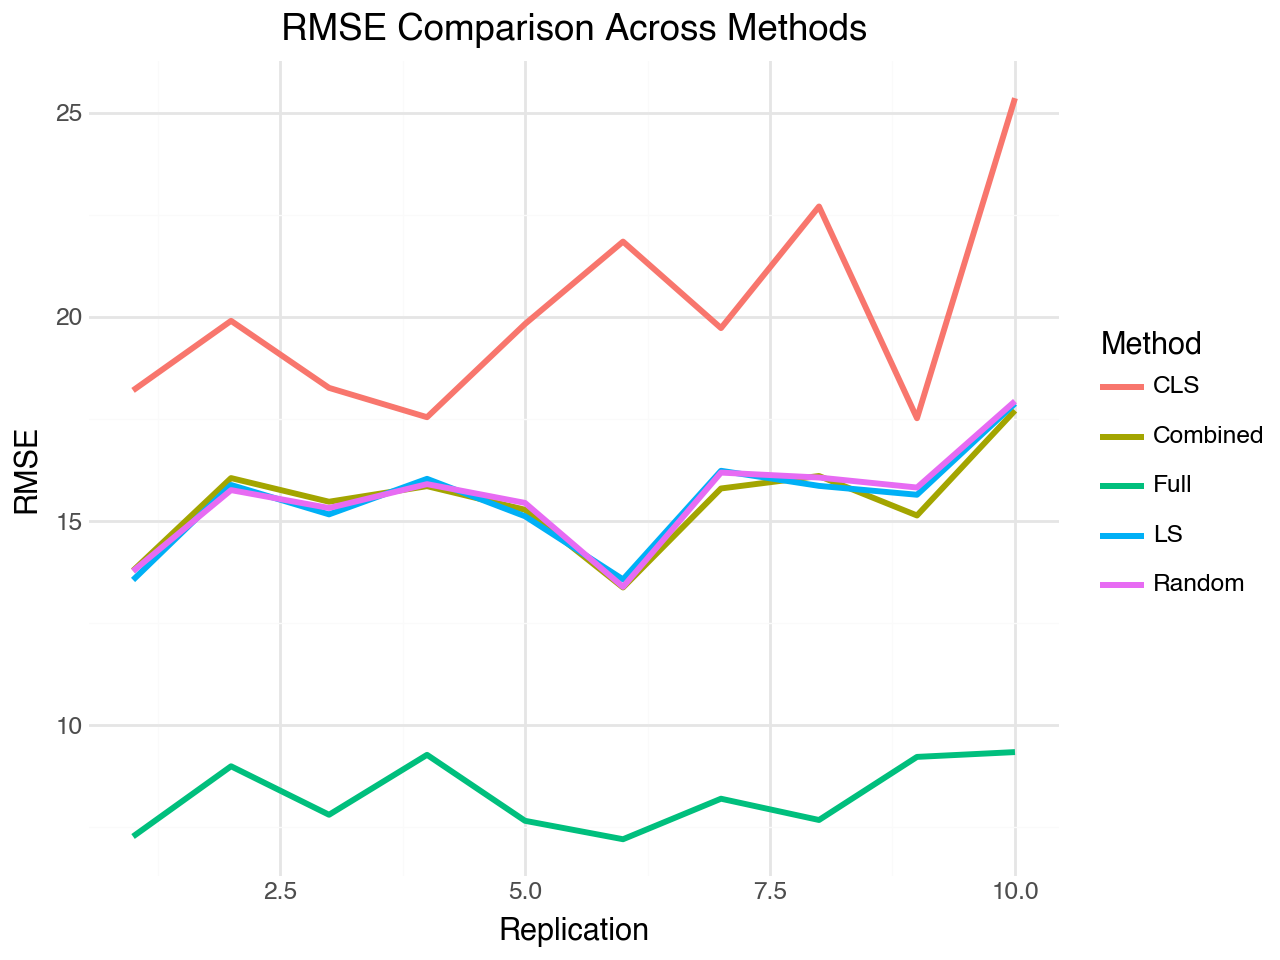

In [133]:
#==============================================================================================
# RMSE Plotting: Building a Line Chart over the RMSE values by Replication
#==============================================================================================

# Index = Replication
rmse_df["Replication"] = np.arange(1, len(rmse_ls) + 1)

# crete long format
rmse_long = rmse_df.melt(
    id_vars="Replication",
    var_name="Method",
    value_name="RMSE"
)
p_line = (
    ggplot(rmse_long, aes(x="Replication", y="RMSE", color="Method"))
    + geom_line(size=1.2)
    + theme_minimal()
    + labs(
        title="RMSE Comparison Across Methods",
        x="Replication",
        y="RMSE"
    )
)
display(p_line)


In [134]:
#### LS Investigation
beta = beta_train[0]
ls = column_ls[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(ls)[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} LS-Spalten sind {len(hits)} korrekt identifiziert")

[271 799 625 609 300 823 982 114 500 682 485 764 351 804 884 873 390 372
 674 496 852 695 134 686 272 461 758 557 831 467 511 492 356 181 366 267
  32 951 742  80  69 927 976 137  62 446 502 885 402 655 525 377 728 404
 443 574 374 325 850 522 730 727 967 122 106 573 683 914 784 596 779 920
 748 971 139 891 364 954 477 640   8]
[  3   6   9  12  13  19  22  23  25  27  42  54  58  60  75  79  83  88
  91 104 109 121 123 128 143 144 149 160 164 175 181 191 193 195 199 204
 206 218 219 221 224 226 227 232 250 256 267 268 271 272 275 277 280 282
 290 292 305 309 311 313 314 318 340 342 343 350 355 356 360 361 368 374
 376 377 380 384 387 391 392 393 396 397 399 400 406 426 427 435 436 438
 442 443 447 459 469 471 473 488 490 493 495 504 510 516 531 535 542 545
 548 551 558 560 563 567 568 569 575 585 590 596 601 602 603 605 608 610
 611 617 618 621 623 625 650 660 673 690 704 705 708 715 720 722 725 730
 740 741 743 747 758 762 771 785 786 790 794 795 804 808 811 815 822 824
 827 845 846 

In [135]:
#### CLS Investigation
cls = column_cls[0] 
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(abs(cls))[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} CLS-Spalten sind {len(hits)} korrekt identifiziert")

[569 388 442 714 176  86 804 220 764  42 673  22 343 148 855 815 282 794
 463 822 496 617  34 771 846 996 725 893 959 503 206 453 305 272 436 928
 271 954  74 180 531 940 886 951 752 144 814  88 122 464 625 268 720 848
   6 875 899 368 618 350 423 611 913 652 623 435 972 232 975 786 218 997
 360 399 469 743 267 387 438 715 950]
[  3   6   9  12  13  19  22  23  25  27  42  54  58  60  75  79  83  88
  91 104 109 121 123 128 143 144 149 160 164 175 181 191 193 195 199 204
 206 218 219 221 224 226 227 232 250 256 267 268 271 272 275 277 280 282
 290 292 305 309 311 313 314 318 340 342 343 350 355 356 360 361 368 374
 376 377 380 384 387 391 392 393 396 397 399 400 406 426 427 435 436 438
 442 443 447 459 469 471 473 488 490 493 495 504 510 516 531 535 542 545
 548 551 558 560 563 567 568 569 575 585 590 596 601 602 603 605 608 610
 611 617 618 621 623 625 650 660 673 690 704 705 708 715 720 722 725 730
 740 741 743 747 758 762 771 785 786 790 794 795 804 808 811 815 822 824
 827 845 846 

In [136]:
#### CS Investigation
cs = column_cs[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(abs(cs))[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} CS-Spalten sind {len(hits)} korrekt identifiziert")

[232  69 443 983 360 936  80 492 877 300 975 374 500 325 758 380 727 404
 343 191 106 850 748 814 356 683 402 822 967 573 467 181 463 502 972 139
  42 752 522 377 920 282 971 873 137 784 914 743 725 804 764 525 927 891
 496 477 271   8 218 435 399 997 364 913 469 779 730 272 640 350 625 875
 951 715 387 596 438 122 950 954 267]
[  3   6   9  12  13  19  22  23  25  27  42  54  58  60  75  79  83  88
  91 104 109 121 123 128 143 144 149 160 164 175 181 191 193 195 199 204
 206 218 219 221 224 226 227 232 250 256 267 268 271 272 275 277 280 282
 290 292 305 309 311 313 314 318 340 342 343 350 355 356 360 361 368 374
 376 377 380 384 387 391 392 393 396 397 399 400 406 426 427 435 436 438
 442 443 447 459 469 471 473 488 490 493 495 504 510 516 531 535 542 545
 548 551 558 560 563 567 568 569 575 585 590 596 601 602 603 605 608 610
 611 617 618 621 623 625 650 660 673 690 704 705 708 715 720 722 725 730
 740 741 743 747 758 762 771 785 786 790 794 795 804 808 811 815 822 824
 827 845 846 

In [137]:
#### RS Investigation
rs = column_rs[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(rs)[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} LS-Spalten sind {len(hits)} korrekt identifiziert")

[618 925 738 453  63 417  34 105 985 989 793 967 865 835 214 299 599 442
 978 522 827 790  76 853 815 535 234 932 572 812 160 583 846 575 695 507
  12 901 886 861 361 609 926 621 471 398 778 515  18 423  31 851 194 332
 142 290 743 841 171 422 801 858 305 954 524  52 666 882 548 138 401 412
 374 493 223 379 906 864 487 641 961]
[  3   6   9  12  13  19  22  23  25  27  42  54  58  60  75  79  83  88
  91 104 109 121 123 128 143 144 149 160 164 175 181 191 193 195 199 204
 206 218 219 221 224 226 227 232 250 256 267 268 271 272 275 277 280 282
 290 292 305 309 311 313 314 318 340 342 343 350 355 356 360 361 368 374
 376 377 380 384 387 391 392 393 396 397 399 400 406 426 427 435 436 438
 442 443 447 459 469 471 473 488 490 493 495 504 510 516 531 535 542 545
 548 551 558 560 563 567 568 569 575 585 590 596 601 602 603 605 608 610
 611 617 618 621 623 625 650 660 673 690 704 705 708 715 720 722 725 730
 740 741 743 747 758 762 771 785 786 790 794 795 804 808 811 815 822 824
 827 845 846 